<br/>
<img src="images/skillnest-logo.png" alt="" width="200px" align="left"/>
<img src="images/skillnest-logo.png" alt="" width="200px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science - Módulo 4</h2><br/>
<h1>Large Language Models (LLMs)</h1>
<br/><br/>
    <b>Instructor Principal:</b> Patricio Olivares polivares@skillnest.com <br/>
    <b>Instructor Asistente:</b> Cristian Sánchez csanchez@skillnest.com<br/><br/>
    <b>Skill Nest</b>
</div>
<br>

# Introducción

## ¿Qué es NLP y por qué es un desafío?

- El Procesamiento del Lenguaje Natural (NLP) busca que las máquinas comprendan y generen lenguaje humano.
- A diferencia de datos estructurados, el lenguaje es ambiguo, complejo y dependiente del contexto.
- Las palabras tienen múltiples significados y las relaciones entre ellas no siempre son explícitas.

## Motivación: de representaciones simples a modelos avanzados

- El primer paso para que una máquina procese texto es convertir las palabras en números.
- Los enfoques básicos como el One-Hot Encoding muestran rápidamente limitaciones: dimensionalidad alta, vectores dispersos y sin relación semántica.
- Surgieron los Word Embeddings para capturar el significado de las palabras de forma densa y significativa.
- Sin embargo, los embeddings clásicos no distinguen entre diferentes usos de una misma palabra.
- Esta limitación llevó a buscar modelos capaces de entender el contexto de cada palabra dentro de una frase.

## Caso real: ejemplos de tareas de NLP

- Traducción automática de idiomas.
- Resumen de textos largos.
- Clasificación de sentimientos en redes sociales.
- Motores de búsqueda que interpretan consultas complejas.
- Chatbots y asistentes conversacionales.


# 1. Representar Texto: De One-Hot a Word Embeddings

## 1.1 El desafío inicial: One-Hot Encoding

- Las redes neuronales trabajan con números, pero el lenguaje está compuesto por palabras.
- La forma más simple de representar palabras es el One-Hot Encoding.
- Cada palabra se convierte en un vector de ceros con un solo uno en la posición correspondiente.
- Ejemplo: Vocabulario ["perro", "gato", "ave"]
  - "perro": [1, 0, 0]
  - "gato": [0, 1, 0]

### Limitaciones de One-Hot Encoding

- Alta dimensionalidad: un vocabulario grande genera vectores muy largos.
- Vectores dispersos: la mayoría de las posiciones son cero.
- No hay relación semántica: todas las palabras son ortogonales entre sí.

## 1.2 Representaciones distribuidas: Word Embeddings

- Los Word Embeddings surgen para resolver las limitaciones del One-Hot Encoding.
- La idea es representar cada palabra como un vector denso de valores continuos.
- En este espacio vectorial, palabras con significados similares están cerca.
- Se capturan relaciones semánticas y sintácticas entre palabras.

## 1.3 Word2Vec y la hipótesis distribucional

- Word2Vec es uno de los modelos más conocidos para aprender embeddings.
- Basado en la hipótesis distribucional: una palabra se entiende por las palabras que la rodean.
- Utiliza grandes corpus de texto para aprender los vectores.
- Ejemplo famoso: rey - hombre + mujer ≈ reina



## Ejemplo: Entrenamiento básico de Word2Vec

- [`gensim`](https://pypi.org/project/gensim/) es una biblioteca popular de Python para modelado de temas y representación vectorial de texto.  
- Permite entrenar y usar modelos como Word2Vec de forma sencilla y eficiente.
- En este ejemplo también usamos [`nltk`](https://www.nltk.org/), una biblioteca de procesamiento de lenguaje natural que facilita tareas como tokenización, lematización, etc.
- **Instalación:** `pip install gensim nltk`

In [ ]:
# Importar Word2Vec y tokenización básica
from gensim.models import Word2Vec

from nltk.tokenize import TreebankWordTokenizer

tokenizer = TreebankWordTokenizer()


# Corpus de ejemplo (muy simple)
corpus = [
    "Los modelos de lenguaje representan palabras como vectores.",
    "Los vectores permiten calcular similitudes semánticas.",
    "Word2Vec es un ejemplo de modelo de embedding estático."
]

# Tokenizar el corpus
tokenized_corpus = [tokenizer.tokenize(sentence.lower()) for sentence in corpus]

# Mostrar corpus tokenizado
print("Corpus tokenizado:")
print(tokenized_corpus)

# Entrenar el modelo Word2Vec
model = Word2Vec(sentences=tokenized_corpus, vector_size=50, window=2, min_count=1, workers=4)

# Consultar vector de una palabra
print("Vector para 'vectores':")
print(model.wv['vectores'])

# Encontrar palabras similares
print("\nPalabras similares a 'vectores':")
print(model.wv.most_similar('vectores'))

Corpus tokenizado:
[['los', 'modelos', 'de', 'lenguaje', 'representan', 'palabras', 'como', 'vectores', '.'], ['los', 'vectores', 'permiten', 'calcular', 'similitudes', 'semánticas', '.'], ['word2vec', 'es', 'un', 'ejemplo', 'de', 'modelo', 'de', 'embedding', 'estático', '.']]
Vector para 'vectores':
[ 1.56359952e-02 -1.90191530e-02 -4.10727109e-04  6.93818601e-03
 -1.87592185e-03  1.67651623e-02  1.80239137e-02  1.30794104e-02
 -1.42345112e-03  1.54198632e-02 -1.70703772e-02  6.41378341e-03
 -9.27488599e-03 -1.01772062e-02  7.18346843e-03  1.07401870e-02
  1.55440327e-02 -1.15269013e-02  1.48646906e-02  1.32472869e-02
 -7.41838338e-03 -1.74954571e-02  1.08777061e-02  1.30169466e-02
 -1.57494494e-03 -1.34195853e-02 -1.41756525e-02 -4.99033043e-03
  1.02834096e-02 -7.32750865e-03 -1.87408887e-02  7.65481405e-03
  9.77040455e-03 -1.28604807e-02  2.41643656e-03 -4.14943462e-03
  5.11142898e-05 -1.97636932e-02  5.38657093e-03 -9.50053148e-03
  2.17646314e-03 -3.15513252e-03  4.39096242e-03

## 1.4 Visualización de embeddings aprendidos

A continuación se muestra cómo reducir la dimensionalidad de algunos vectores de palabras y graficarlos para ver cuáles quedan cerca y cuáles lejos.

Se usa PCA para proyectar los embeddings a 2D.

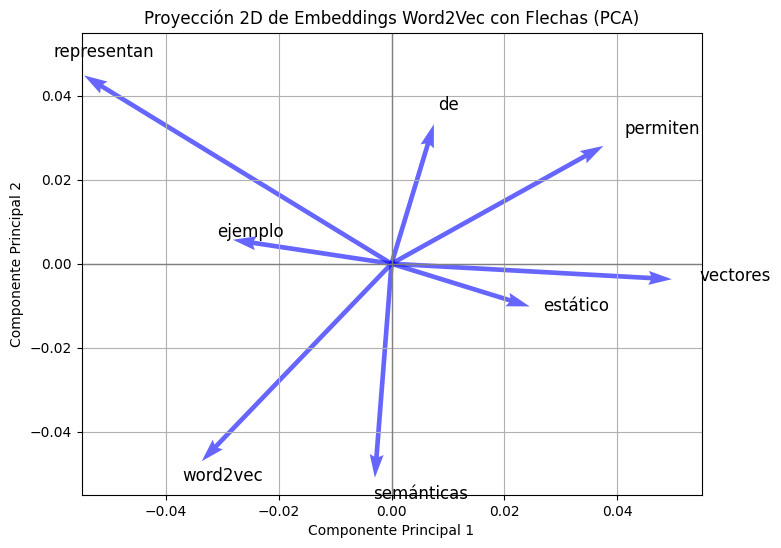

In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Elegir palabra central y encontrar palabras similares
word = 'vectores'
similar_words = model.wv.most_similar(word, topn=5)

# Palabras para graficar: palabra central + similares + algunas aleatorias
words = [word] + [w for w, _ in similar_words] + ['representan', 'ejemplo']

# Obtener vectores
word_vectors = [model.wv[w] for w in words]

# Reducir a 2D con PCA
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

# Graficar con flechas
plt.figure(figsize=(8, 6))

origin_x = [0] * len(result)
origin_y = [0] * len(result)

plt.quiver(
    origin_x, origin_y,
    result[:, 0], result[:, 1],
    angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.6
)

# Anotar cada palabra
for i, w in enumerate(words):
    plt.text(result[i, 0]*1.1, result[i, 1]*1.1, w, fontsize=12)

plt.title("Proyección 2D de Embeddings Word2Vec con Flechas (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.show()

## 1.5 Limitaciones de los embeddings clásicos

- Los embeddings como Word2Vec generan vectores estáticos.
- El mismo vector se usa para una palabra sin importar el contexto.
- Ejemplo: "banco" en "guardar dinero en el banco" y "sentarse en el banco del parque" es representado igual.
- Esta limitación impulsó el desarrollo de modelos que generan representaciones dependientes del contexto.

## 2. Embeddings Contextualizados

- Los embeddings estáticos usan un solo vector por palabra.
- No consideran el contexto de la oración.
- Los embeddings contextualizados resuelven este problema.
- BERT es un modelo popular para generar estos embeddings.
- Analiza cada palabra considerando el contexto bidireccional.
- Permiten captar significados diferentes según el uso.
- Son útiles para clasificación, respuesta a preguntas y análisis de sentimientos.


### Ejemplo: Extracción de embeddings contextualizados con BERT

- Para obtener embeddings contextualizados se usa un modelo preentrenado como BERT.
- BERT está preentrenado con grandes corpus de texto para predecir palabras faltantes y la relación entre frases.
- Esto le permite generar vectores que capturan significados según el contexto de cada palabra.
- Usaremos las bibliotecas `transformers` y `torch` para tokenizar el texto y extraer los vectores.


In [ ]:
# Instalar librerías necesarias (si aún no están instaladas)
# pip install transformers torch

from transformers import BertTokenizer, BertModel
import torch

# Cargar el tokenizer y el modelo preentrenado
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Texto de ejemplo. En inglés por entrenamiento de BERT
text = "The bank can guarantee deposits will eventually cover future tuition costs."

# Tokenizar y convertir a tensores
inputs = tokenizer(text, return_tensors='pt')
input_ids = inputs['input_ids'][0]  # Tomamos el batch único

print("Input IDs:", input_ids.tolist())

# Decodificar cada ID a su token correspondiente
tokens = tokenizer.convert_ids_to_tokens(input_ids)
print("Tokens decodificados:", tokens)

# Obtener embeddings con el modelo BERT
with torch.no_grad():
    outputs = model(**inputs)

# Extraer embeddings de la capa de salida
last_hidden_states = outputs.last_hidden_state

print("Shape del tensor de embeddings:", last_hidden_states.shape)
print("Embeddings de la primera palabra tokenizada:", last_hidden_states[0][0])

Input IDs: [101, 1996, 2924, 2064, 11302, 10042, 2097, 2776, 3104, 2925, 15413, 5366, 1012, 102]
Tokens decodificados: ['[CLS]', 'the', 'bank', 'can', 'guarantee', 'deposits', 'will', 'eventually', 'cover', 'future', 'tuition', 'costs', '.', '[SEP]']
Shape del tensor de embeddings: torch.Size([1, 14, 768])
Embeddings de la primera palabra tokenizada: tensor([ 1.2593e-03, -4.5964e-01,  2.7312e-01,  6.1500e-01,  3.3914e-01,
        -4.2774e-01, -2.2393e-01,  6.2196e-01,  4.7013e-02, -2.7728e-01,
        -2.6388e-01, -5.4767e-02,  4.3113e-01, -1.9061e-02,  1.6850e-01,
        -4.5282e-01, -6.8110e-02,  4.1262e-01,  2.3356e-01, -6.5013e-01,
        -6.7799e-01,  1.3478e-01,  3.3967e-02,  3.2392e-01,  2.6599e-02,
        -6.4166e-02,  3.0429e-01, -9.5883e-02,  1.5753e-01,  1.7689e-01,
         3.5833e-01, -1.3003e-01, -2.4608e-01, -4.6858e-01,  6.8526e-01,
        -2.2980e-01, -1.1272e-01, -5.3923e-01, -1.2699e-01, -8.5983e-02,
        -1.0247e-01,  3.1383e-01,  3.8872e-01,  7.6800e-02, -2.

## 3. Transformer y Mecanismo de Atención

- Los modelos secuenciales clásicos procesan palabras una por una, lo que limita la paralelización.
- El Transformer resuelve esta limitación usando atención para procesar palabras en paralelo.
- La atención permite que cada palabra se relacione con otras en la misma oración.
- El mecanismo de atención calcula pesos para cada relación entre palabras.
- Esto mejora la capacidad del modelo para capturar dependencias a largo plazo.
- La arquitectura del Transformer usa capas de atención y capas feed-forward.
- BERT y GPT se basan en la arquitectura Transformer para generar embeddings.
- Visualizar los pesos de atención ayuda a entender qué palabras influencian más a otras.


### Ejemplo: Cálculo del mecanismo de atención en TensorFlow

- Este ejemplo muestra cómo se calculan las matrices Query, Key y Value.
- Se usa una secuencia de entrada pequeña con una capa densa para cada matriz.
- Se calculan los pesos de atención escalados usando producto punto y softmax.
- Finalmente, se combinan los valores según estos pesos para obtener la salida.


In [21]:
import tensorflow as tf

# Matriz de entrada simulada embedding (batch_size=1, secuencia de 3 palabras, dimensión de 4)
x = tf.constant([[[1.0, 0.0, 1.0, 0.0],
                  [0.0, 2.0, 0.0, 2.0],
                  [1.0, 1.0, 1.0, 1.0]]])

print("Input:", x.numpy())

# Pesos para Q, K, V (simulados para este ejemplo)
wq = tf.keras.layers.Dense(2)  # Query de dimensión 2
wk = tf.keras.layers.Dense(2)  # Key de dimensión 2
wv = tf.keras.layers.Dense(2)  # Value de dimensión 2

# Calcular Q, K, V
q = wq(x)
k = wk(x)
v = wv(x)

print("\nQuery:\n", q.numpy())
print("\nKey:\n", k.numpy())
print("\nValue:\n", v.numpy())

# Cálculo de atención escalada
matmul_qk = tf.matmul(q, k, transpose_b=True)
dk = tf.cast(tf.shape(k)[-1], tf.float32)
scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

# Softmax para obtener pesos de atención
attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
print("\nAttention weights:\n", attention_weights.numpy())

# Producto de los pesos por los valores
output = tf.matmul(attention_weights, v)
print("\nOutput de la capa de atención:\n", output.numpy())


Input: [[[1. 0. 1. 0.]
  [0. 2. 0. 2.]
  [1. 1. 1. 1.]]]

Query:
 [[[ 0.29016066  0.5598736 ]
  [-1.4873667   2.3562498 ]
  [-0.45352268  1.7379985 ]]]

Key:
 [[[-1.1692355   1.3264279 ]
  [-1.7806506  -2.2952266 ]
  [-2.0595608   0.17881465]]]

Value:
 [[[ 0.2886653   0.02074242]
  [ 1.7003326  -3.2780046 ]
  [ 1.1388316  -1.6182599 ]]]

Attention weights:
 [[[0.5749853  0.1209188  0.30409595]
  [0.723855   0.00329868 0.27284628]
  [0.7468817  0.01060311 0.2425152 ]]]

Output de la capa de atención:
 [[[ 0.71789455 -0.8765521 ]
  [ 0.5252866  -0.43733478]
  [ 0.50981164 -0.41171753]]]


## 4. Multi-Head Attention y Arquitectura Encoder-Decoder

- El mecanismo de Multi-Head Attention permite que el modelo aprenda diferentes relaciones en paralelo.
- Cada cabeza de atención enfoca patrones distintos de dependencia entre palabras.
- Los resultados de todas las cabezas se combinan y pasan por una capa densa.
- La arquitectura Encoder-Decoder usa múltiples bloques de atención y capas feed-forward.
- El Encoder procesa la entrada y genera representaciones internas.
- El Decoder utiliza estas representaciones para generar la salida paso a paso.
- Esta arquitectura es clave en tareas como traducción automática y resumen de texto.
- Modelos como BERT usan solo la parte Encoder; GPT usa solo la parte Decoder.


### Ejemplo: Multi-Head Attention con TensorFlow

- Multi-Head Attention permite al modelo aprender diferentes patrones de relación en paralelo.
- Cada cabeza de atención aplica su propio mecanismo de atención sobre la misma entrada.
- Los resultados se combinan para capturar información de contexto de múltiples formas.
- Este ejemplo usa la capa `MultiHeadAttention` de Keras para mostrar cómo funciona la atención múltiple.

In [22]:
import tensorflow as tf

# Crear datos de entrada simulados
# batch_size=1, secuencia de 4 tokens, dimensión de 8
x = tf.random.uniform((1, 4, 8))

print("Input shape:", x.shape)

# Definir capa de Multi-Head Attention
# 2 cabezas de atención, cada una de dimensión 4
mha = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=4)

# Usar la misma entrada como query, key y value (self-attention)
output, weights = mha(query=x, value=x, key=x, return_attention_scores=True)

print("Output shape:", output.shape)
print("Attention weights shape:", weights.shape)
print("Attention weights:", weights.numpy())


Input shape: (1, 4, 8)
Output shape: (1, 4, 8)
Attention weights shape: (1, 2, 4, 4)
Attention weights: [[[[0.26714304 0.23016831 0.26134363 0.24134502]
   [0.26870272 0.24377517 0.25719377 0.23032834]
   [0.25914097 0.2366311  0.25624746 0.24798049]
   [0.24910803 0.2521969  0.25642815 0.24226691]]

  [[0.26123604 0.24915606 0.24127147 0.24833648]
   [0.26825303 0.24007636 0.24373837 0.24793226]
   [0.25266546 0.25536826 0.24791601 0.24405025]
   [0.2618595  0.24473718 0.24358146 0.24982186]]]]
